<a href="https://colab.research.google.com/github/sjkim25/Introduction-to-Artificial-Intelligence/blob/main/week12/TSLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TSLA.csv')
data = df['Close'].values.reshape(-1,1)

In [2]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
scaled = scaler.fit_transform(data)

In [3]:
TEST_SIZE = 2400
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]

In [4]:
def make_sample(data, window):
  train = []
  target = []
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train), np.array(target)

X_train, y_train = make_sample(train_data, 30)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

model = Sequential()
model.add(SimpleRNN(30, activation='tanh', input_shape=(30, 1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=16)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.4022e-04
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1955e-06
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1897e-06
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0958e-06
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0401e-06
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8141e-07
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.5913e-07
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2293e-07
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5886e-07
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.1903e-07
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.1176e-07
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.7227e-07
Epoch 13/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.1385e-07
Epoch 14/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.9338e-07
Epoch 15/100
33

In [7]:
X_test, y_test = make_sample(test_data, 30)
pred = model.predict(X_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


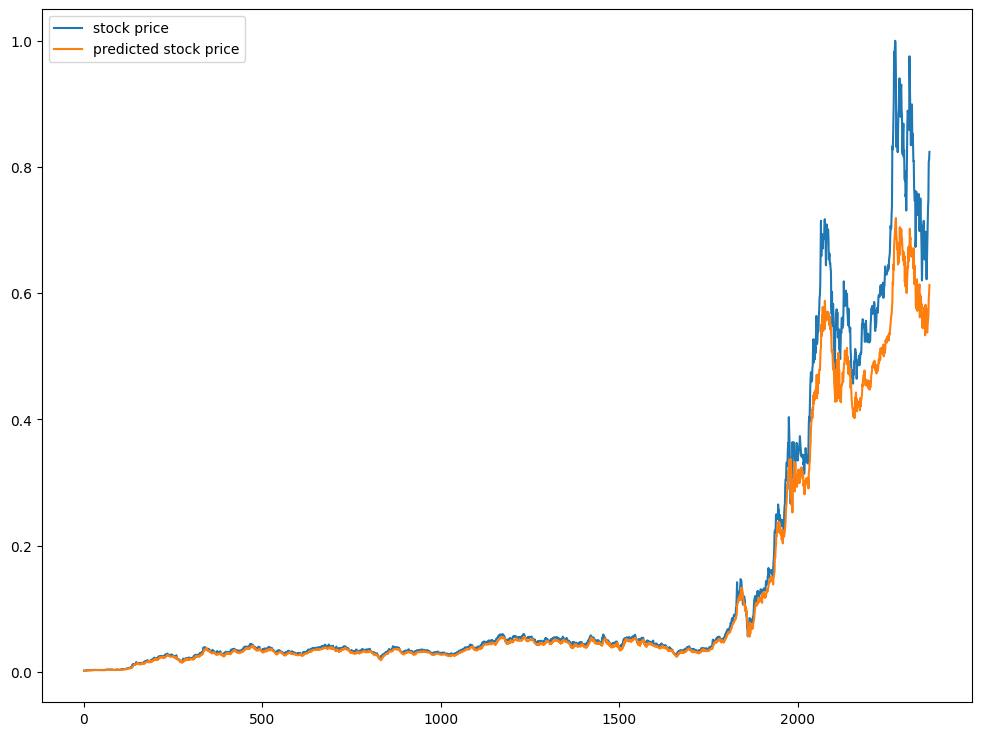

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
plt.plot(y_test, label='stock price')
plt.plot(pred, label='predicted stock price')
plt.legend()
plt.show()